<a href="https://colab.research.google.com/github/MarianaCastrillonM004/Integracion-de-prospectiva-y-datos/blob/main/Taller_de_credibilidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Fallos Tecnológicos - FINTECH**

Se plantea como caso de estudio el analisis de las perdidas generadas en el riesgo derivado de las operaciones del negocio de una Fintech.

Estos son los riegos son los que se presentan en canales electrónico.

* **Frecuencia:** Indica el numero de fallas electronicas que manifiestan los usuarios cada día (tiempo)

* **Severidad:** Indica el costo de solucionar cada evento de riesgo (millones)

* **Distribucion agregada de pérdidas:** producto entre la severidad y la frecuencia

* **Credibilidad de los datos (cr):** Porcentaje que indica la credibilidad d elos datos externos para su integracion en datos internos.

* **Distribucion agregada de pérdidas:**

Es importante mencionar que el producto entre la severidad y la frecuencia da como resultado la distribucion agregada de las pérdidas (LDA - Loss Distribution Approach) y es precisamente que se hará la caracterización de esta distribución utilizando las medidas de tendencia central (media y desviaciÓn) y las medidas de dispersión (coeficiente de asimetría y kurtosis).





0. Cargar librerias de trabajo

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns #libreria para trabajo estadistico
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Creacion de funcion para guardar formulas estadisticas

In [7]:
def caracterizacion(LDA, title=""): # Add a title argument

  #Se procede con la creación de la distribución
  plt.figure(figsize=(10,5))
  sns.histplot(LDA,bins=10,kde=True)
  plt.xlabel("Pérdida (KUSD)")
  plt.title(title) # Set the plot title
  plt.grid()
  plt.show()

  #Se procede con la caracterización de cada una de las variables
  np.set_printoptions(suppress=True)
  NI=10    #Indica el número de clusters
  counts,bin_edges=np.histogram(LDA,bins=NI)
  print("El número de datos por intervalo es:")
  print(counts)
  print("Los intervalos inferiores:")
  print(bin_edges[:-1])
  print("Los intervalos superiores:")
  print(bin_edges[1:])
  XC=(bin_edges[:-1]+bin_edges[1:])/2

  #Se configura la tabla de los datos
  Tabla=np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
  df=pd.DataFrame(Tabla,columns=['LI','LS','XC','ND'])
  df.head(10)

  #Se procede con la estimación de la media
  fr=counts/np.sum(counts)
  u=np.sum(XC*fr)
  sigma2=np.sum(fr*(XC-u)**2)
  sigma=np.sqrt(sigma2)
  Cas=np.sum(fr*(XC-u)**3)/sigma**3
  Kur=(np.sum(fr*(XC-u)**4)/sigma**4)-3

  return u,sigma,Cas,Kur,df

2. Se cargan los archivos de trabajo y se comparan medidas estadísticas

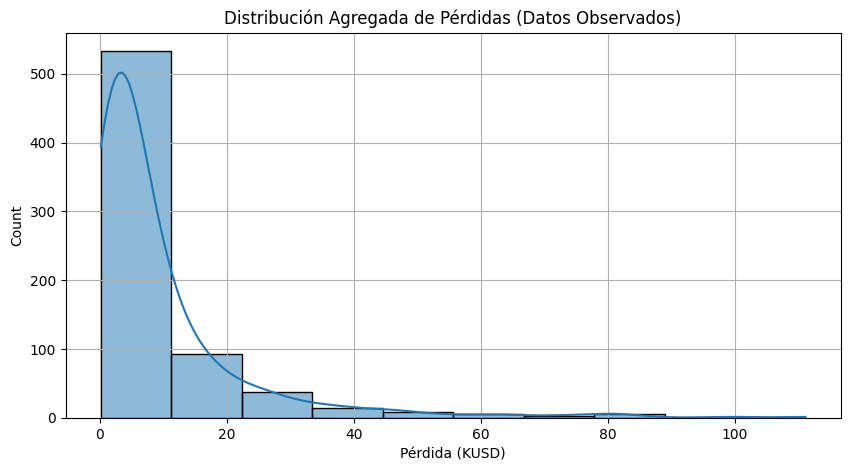

El número de datos por intervalo es:
[533  93  37  14   9   5   3   5   1   1]
Los intervalos inferiores:
[ 0.1423  11.23637 22.33044 33.42451 44.51858 55.61265 66.70672 77.80079
 88.89486 99.98893]
Los intervalos superiores:
[ 11.23637  22.33044  33.42451  44.51858  55.61265  66.70672  77.80079
  88.89486  99.98893 111.083  ]
La media de los datos observados es: 11.07019634094151
El coeficiente de asimetria es: 3.5824155186772604


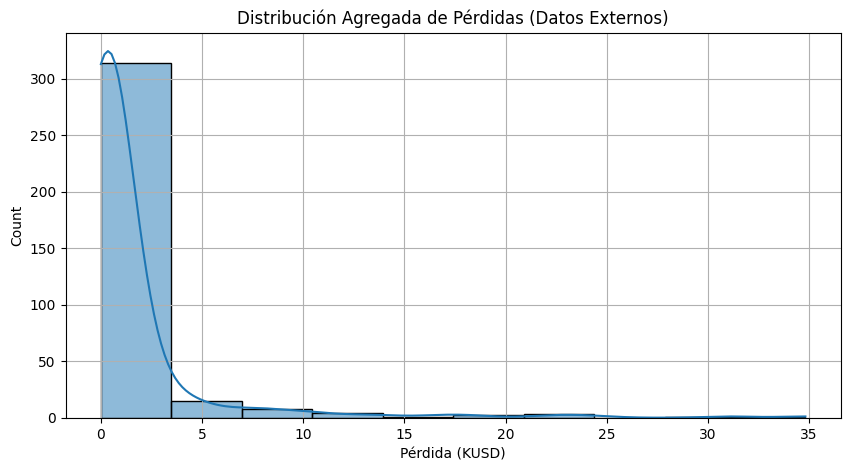

El número de datos por intervalo es:
[314  15   8   4   1   2   3   0   1   1]
Los intervalos inferiores:
[ 0.          3.48221562  6.96443124 10.44664686 13.92886248 17.4110781
 20.89329372 24.37550933 27.85772495 31.33994057]
Los intervalos superiores:
[ 3.48221562  6.96443124 10.44664686 13.92886248 17.4110781  20.89329372
 24.37550933 27.85772495 31.33994057 34.82215619]
La media de los datos externos es: 2.659055766504145
El coeficiente de asimetria es: 5.305045914196857
El valor esperado de la varianza es: 117.95702483229815
La credibilidad de la base de datos Externa es:  0.010604763259661198
Se conoce como la franquicia las perdidas:  2.748253921039784


In [8]:
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#1. Aqui se carga la base de datos interna (Datos Obervados)
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
nxl='/content/drive/MyDrive/UNIVERSIDAD/Enfasis/Archivos I&P/1. FallasTecnológicas - Taller.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)
XDB.head(10)

#Procedemos con la construcción de la distribución agregada de las pérdidas
Freq=pd.to_numeric(XDB.iloc[1:,3], errors='coerce')
Sev=pd.to_numeric(XDB.iloc[1:,4], errors='coerce')
LDA=Freq*Sev

#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#2. Se procede con la carga de la base de datos (Datos Externos - HAPAG Lloyd)
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
nxle='/content/drive/MyDrive/UNIVERSIDAD/Enfasis/Archivos I&P/2. AdmonEjecProcesos.xlsx'
XDBe = pd.read_excel(nxle,sheet_name=0)
XDBe.head(10)

Freqe=pd.to_numeric(XDBe.iloc[1:,3], errors='coerce')
Seve=pd.to_numeric(XDBe.iloc[1:,4], errors='coerce')
LDAe=Freqe*Seve

#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#3. Comparación Estadística (Media, Varianza, Desviación, Asimetriía, Kurtosis)
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#3.1. Bases de Datos Observados (EVERGREEN)
u,sigma,Cas,Kur,df=caracterizacion(LDA, title='Distribución Agregada de Pérdidas (Datos Observados)') # Pass a title
print("La media de los datos observados es:", u)
print("El coeficiente de asimetria es:", Cas)

#3.2. Bases de Datos Externas (Hapag Lloyd)
uoe, sigamoe, Casoe, Kurtoe, dfoe=caracterizacion(LDAe, title='Distribución Agregada de Pérdidas (Datos Externos)') # Pass a title
print("La media de los datos externos es:", uoe)
print("El coeficiente de asimetria es:", Casoe)

#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#4. Teoría de credibilidad
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#4.1 Media hipotética

NDo=len(LDA); NDe=len(LDAe) #NDo/NDe: numero de datos observados/externos
uhat=(NDo*u+NDe*uoe)/(NDo+NDe) #uhat media hipotética

#4.2 EPV: Valor esperado de la varianza
EPV=(NDo*sigma**2+NDe*sigamoe**2)/(NDo+NDe)
print("El valor esperado de la varianza es:", EPV)

#4.3 VHM: Varianza hipotetica de la media
VHM=((NDo*u**2+NDe*uoe**2)/(NDo+NDe))-uhat**2

#4.4 Factor de credibilidad
fc=EPV/VHM

#4.5 Credibilidad de la base de datos
Cr=1-NDo/(NDo+fc)
print("La credibilidad de la base de datos Externa es: ", Cr) #Evaluamos la credibilida de la base de datos externa pues es sabido que confiamos en nuestros propios datos.

#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#5. Parametros de riesgo
#'''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
#5.1 Perdidas esperadas y asumibles (media:Franquicia): Media hipotetica de los datos integrados

PEs=Cr*u+(1-Cr)*uoe
print("Se conoce como la franquicia las perdidas: ", PEs)

Análisis de credibilidad De acuerdo con las bases de datos disponibles para este estudio, podemos observar que que las bases de datos a priori tuvieron una media de datos muy distinta (u:11.07, uoe:2.65), esto se pudo evidenciar igualmente a traves del coeficiente de asiemtria, el cual indica una gran diferencia en acumulacion de perdidas en las operaciones tecnologicas de estos bancos (Cas:3.58, Casoe:5.3). De acuerdo con la diferencia de las metricas anyeriores, el coeficiente de credibilidad que, evalua la calidad de los datos externos, nos indica que este alcanzó un valor de tan solo el 1% en promedio, lo que indica que el 1% de los datos externos se pueden integrar con los datos internos.

3. Análsis montecarlo de nuestros datos internos


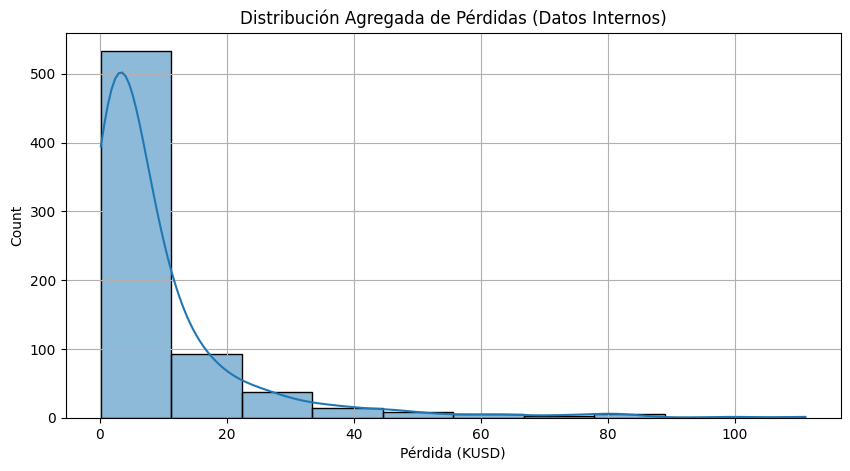

El número de datos por intervalo es:
[533  93  37  14   9   5   3   5   1   1]
Los intervalos inferiores:
[ 0.1423  11.23637 22.33044 33.42451 44.51858 55.61265 66.70672 77.80079
 88.89486 99.98893]
Los intervalos superiores:
[ 11.23637  22.33044  33.42451  44.51858  55.61265  66.70672  77.80079
  88.89486  99.98893 111.083  ]


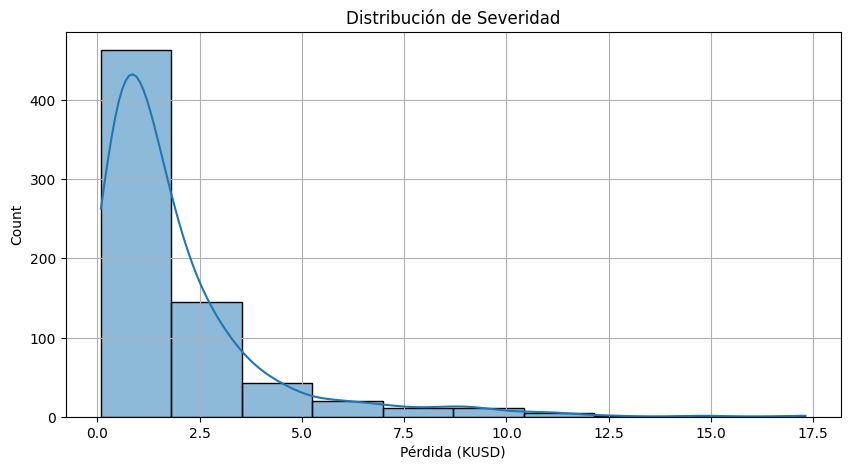

El número de datos por intervalo es:
[463 145  43  20  11  11   5   1   1   1]
Los intervalos inferiores:
[ 0.0842   1.80707  3.52994  5.25281  6.97568  8.69855 10.42142 12.14429
 13.86716 15.59003]
Los intervalos superiores:
[ 1.80707  3.52994  5.25281  6.97568  8.69855 10.42142 12.14429 13.86716
 15.59003 17.3129 ]


In [9]:
#Se procede con la estimación de las propiedades estadísticas
p1,p2,p3,p4,df=caracterizacion(LDA, title='Distribución Agregada de Pérdidas (Datos Internos)') # Pass a title

#Ahora se puede obtener las propiedades de la variable severidad
p1,p2,p3,p4,df=caracterizacion(Sev, title='Distribución de Severidad') # Pass a title

In [6]:
u=np.mean(LDA)
var=np.var(LDA)
sigma=np.std(LDA) # Corrected: Calculate standard deviation of LDA

T2=np.column_stack((u,var,sigma))
df2=pd.DataFrame(T2,columns=['Media','Varianza','Desviacion'])
df2.head(1)
from scipy.stats import skew, kurtosis

# Calculate skewness
lda_skew = skew(LDA)

# Calculate kurtosis
lda_kurtosis = kurtosis(LDA)

# Optionally, add to the DataFrame with other metrics
df2_temp = df2.copy()
df2_temp['Asimetria'] = lda_skew
df2_temp['Kurtosis'] = lda_kurtosis

display(df2_temp)

,Media,Varianza,Desviacion,Asimetria,Kurtosis
0,9.451113,187.894776,13.707472,3.34836,14.167714


#**Análisis de resultados**

Al analizar los datos internos y sus medidas de tendencia central observamos que segun la distribucion, estso datos tienden a ubicarse por debajo de la media como se muestra en el coeficiente de asimetria (3.34) y este a su vez esta por encima de la unidad, lo que quiere decir que las perdidas generadas por los falos tecnológicos son minimos. El coeficiente de la curtosis (14.16) muestra que los datos estan al lado izquiero de la distribucion, lo que de nuevo nos asegura que las perdidas son minimas, es decir, son esperadas.

Respecto al analisis de credibilidad, la media de los datos internos y los datos externos es drásticamente distinta (u:11.07, uoe:2.65), y nuestro porcentaje de credibilidad para integrar esos datos nos dio un pequeño 1%, es decir que solo el 1% de los datos nos serviria para trabajar e integralo con los datos de la fintech.